# CISC 121 – Assignment-3

## 🔗 Problem
 Solve **one problem** from each of the five categories.

### Stacks:

- Valid Parentheses ([LeetCode 20](https://leetcode.com/problems/valid-parentheses/))
- Daily Temperatures ([LeetCode 739](https://leetcode.com/problems/daily-temperatures/description/))


### Queues:

- Number of Students Unable to Eat Lunch ([LeetCode 1700](https://leetcode.com/problems/number-of-students-unable-to-eat-lunch/description/?envType=problem-list-v2&envId=queue))
- Number of People Aware of a Secret ([LeetCode 2327](https://leetcode.com/problems/number-of-people-aware-of-a-secret/description/?envType=problem-list-v2&envId=queue))


### Recursion

- Climbing Stairs ([LeetCode 70](https://leetcode.com/problems/climbing-stairs/))
- Power of Three ([Leetcode 326](https://leetcode.com/problems/power-of-three/description/?envType=problem-list-v2&envId=recursion))

### Searching Problems:

- First Bad Version ([LeetCode 278](https://leetcode.com/problems/first-bad-version/description/))
- Find First and Last Position of Element in Sorted Array ([LeetCode 34](https://leetcode.com/problems/find-first-and-last-position-of-element-in-sorted-array/description/))

### Sorting Problems:

- Valid Anagram ([LeetCode 242](https://leetcode.com/problems/valid-anagram/description/))
- Sort Colors ([LeetCode](https://leetcode.com/problems/sort-colors/description/))


1. Your Name:haochen yu
2. Section:001
3. ID:20513784
4. Github Link of this notebook:https://github.com/Starfish1202/note-book
5. Chat link with AI tool: https://chatgpt.com/c/6916c385-3770-8333-bc26-855f845bc74g

#  Problem 1：Valid Parentheses




## 1. Understanding & Breakdown

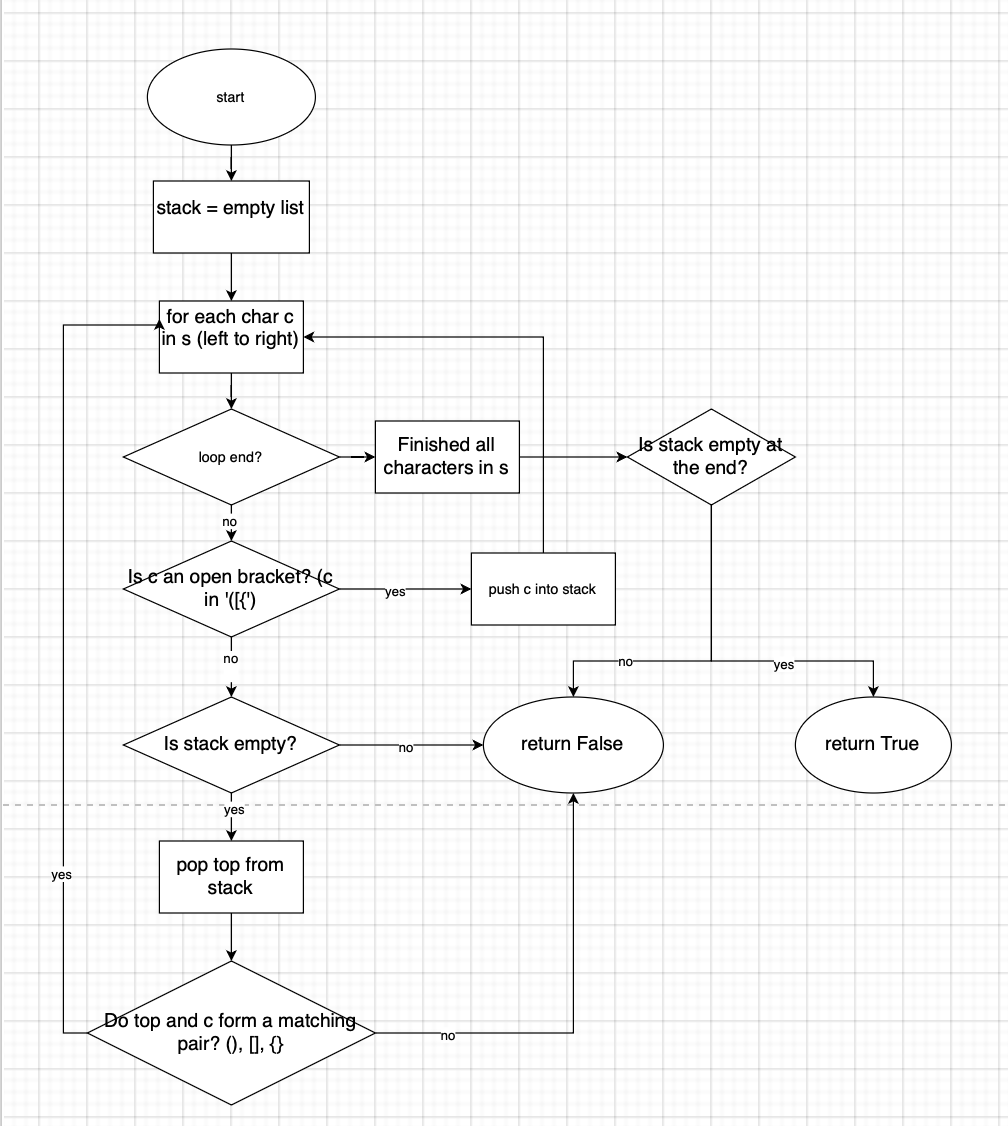

## 2. Peer Review & Draft Code



I reviewed the top solution under the LeetCode “Solutions” tab and one post on Stack Overflow:  
https://stackoverflow.com/questions/17129222/how-to-check-if-a-number-is-palindrome-in-python  

When I compared a few other solutions, I noticed they all used a stack as the main structure, which helped me understand why the unmatched open brackets become the core invariant of the problem.



In [ ]:
# Draft Code (Valid Parentheses)
# [AI Disclaimer: Used ChatGPT with prompt "stack + matching parentheses concept" only for concept]

class Solution(object):
    def isValid(self, s):
        """
        :type s: str
        :rtype: bool
        """
        stack = []  # use list as stack for open brackets
        pairs = {')': '(', ']': '[', '}': '{'}

        for c in s:
            # if c is an open bracket, push to stack
            if c == '(' or c == '[' or c == '{':
                stack.append(c)
            else:
                # if stack is empty, there is no matching open bracket
                if not stack:
                    return False
                top = stack.pop()
                # check if current close bracket matches the last open bracket
                if pairs[c] != top:
                    return False

        # if stack is empty, all brackets were matched
        return len(stack) == 0


## 3. Final Correct Code

_This version must pass all required test cases and handle edge cases correctly._

At this stage, you may:
- Use reviewed solutions or programming AI tools (e.g., ChatGPT, GitHub Copilot) to refine and fix errors.
- Refactor your draft to ensure accuracy and completeness.

 **AI Level 4 is allowed**, but you **must include a disclaimer** that clearly states what tools you used, how you used them, and for which part of the code.


In [ ]:
# Final working solution
class Solution(object):
    def isValid(self, s):
        """
        :type s: str
        :rtype: bool
        """
        stack = []  # stack to store unmatched open brackets
        pairs = {')': '(', ']': '[', '}': '{'}

        for c in s:
            # push open bracket into stack
            if c in pairs.values():
                stack.append(c)
            else:
                # must match an existing open bracket
                if not stack:
                    return False
                top = stack.pop()
                if pairs.get(c) != top:
                    return False

        # valid only when no open brackets are left
        return len(stack) == 0




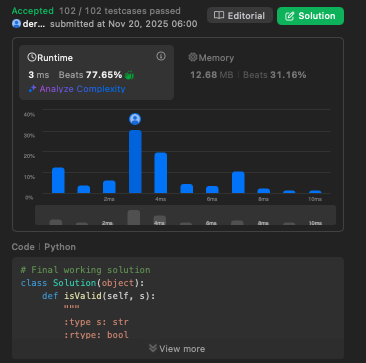

## 4. Review & Fixes
_What did you improve from your draft? 2 fixes with your comments._



In [ ]:
# Fix 1：

# Draft version (Used if c == '(' or c == '[' or c == '{':, which is repetitive and harder to maintain.)
for c in s:
            # if c is an open bracket, push to stack
            if c == '(' or c == '[' or c == '{':
                stack.append(c)
            else:
                # if stack is empty, there is no matching open bracket
                if not stack:
                    return False
                top = stack.pop()
                # check if current close bracket matches the last open bracket
                if pairs[c] != top:
                    return False

# Fixed version (cleaner and direct)
for c in s:
            # push open bracket into stack
            if c in pairs.values():
                stack.append(c)
            else:
                # must match an existing open bracket
                if not stack:
                    return False
                top = stack.pop()
                if pairs.get(c) != top:
                    return False


In [ ]:
# Fix 2:

# Draft version: Used pairs[c] when checking a closing bracket. This assumes the key always exists and is less explicit about the intention.
if pairs[c] != top:
    return False

# Fixed version: safer and clearer
if pairs.get(c) != top:
    return False


## 5. Reflection on Your Contribution
_Where did AI or Other's code helped or fail to help? What specific logic or debugging did you contribute yourself?_

1.Most of the logic came from my own notes. I mainly followed the idea of using a stack as the invariant to track unmatched open brackets and then translated that into code step by step.

2.  I only used AI to double-check the stack matching concept and to confirm whether using a dictionary for bracket pairs is a clean approach. No code was copied, and the testing and adjustments were done by myself.




#  Problem 2：Number of People Aware of a Secret




## 1. Understanding & Breakdown

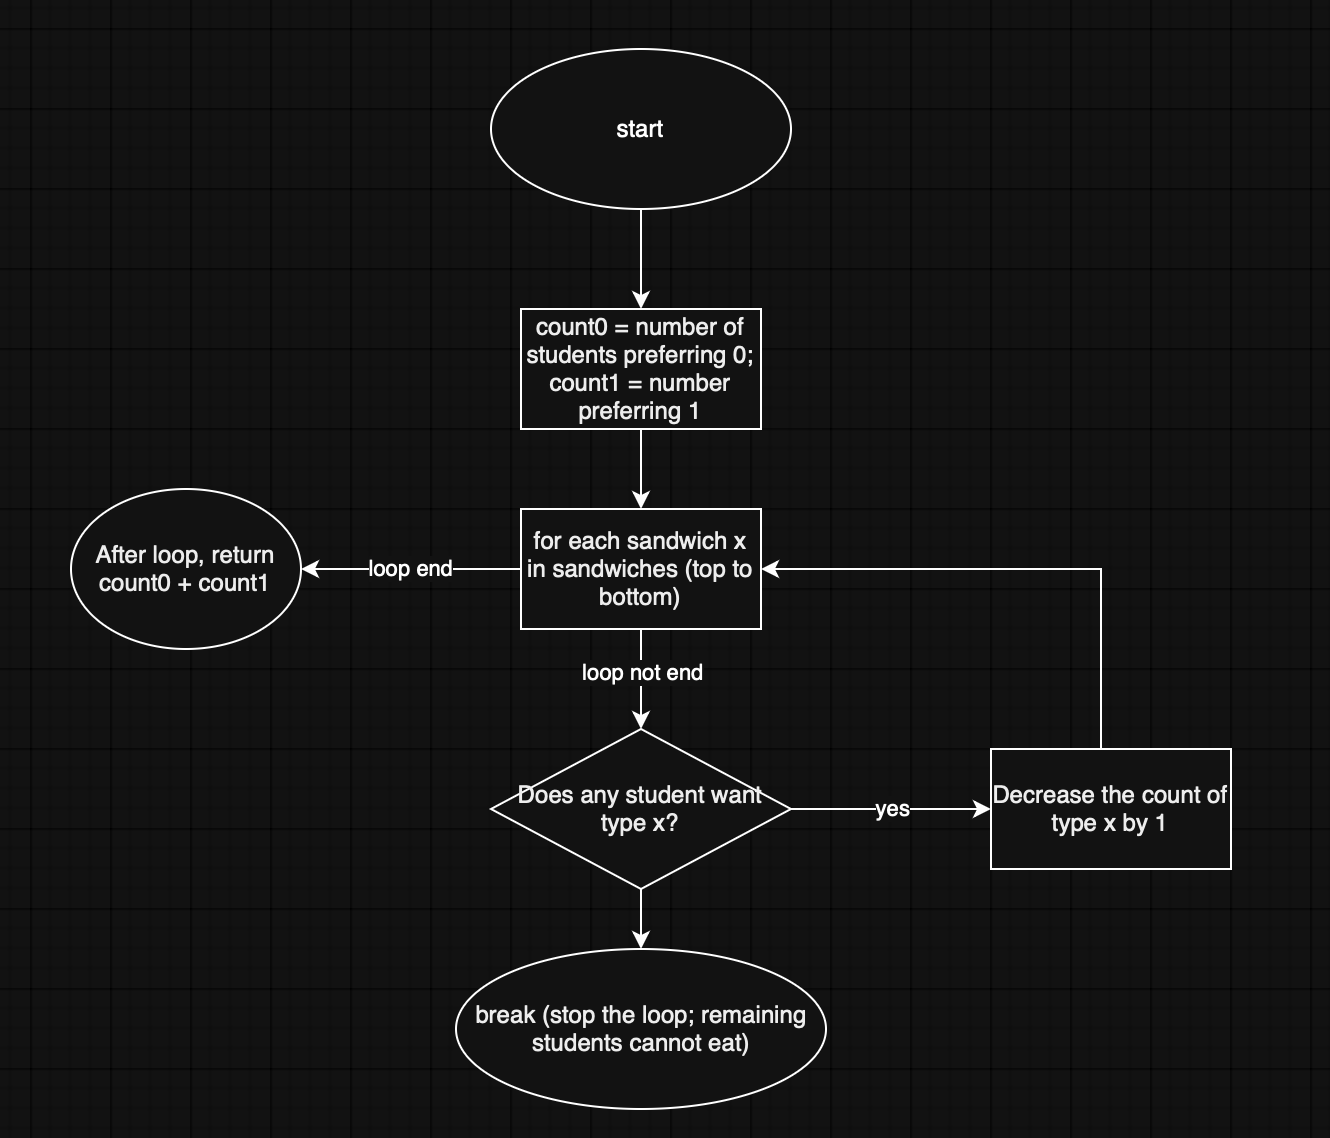

## 2. Peer Review & Draft Code


I reviewed the top solution under the LeetCode “Solutions” tab:  
https://leetcode.com/problems/number-of-students-unable-to-eat-lunch/solutions/4990164/beats-9893-extra-easy-solution-with-expl-1ret/?envType=problem-list-v2&envId=queue
*   I learned that we do not need to simulate the whole queue rotation. The
important idea is that the process stops exactly when the current sandwich type has no students left who prefer it.



In [ ]:
class Solution(object):
    def countStudents(self, students, sandwiches):
        """
        :type students: List[int]
        :type sandwiches: List[int]
        :rtype: int
        """
        # try to simulate using counts instead of full queue rotation
        count0 = 0
        count1 = 0

        # count student preferences
        for s in students:
            if s == 0:
                count0 += 1
            else:
                count1 += 1

        # go through sandwiches from the top
        for sw in sandwiches:
            if sw == 0:
                if count0 == 0:
                    return count1   # only 1-type students left
                count0 -= 1
            else:
                if count1 == 0:
                    return count0   # only 0-type students left
                count1 -= 1

        # everybody was served
        return 0

## 3. Final Correct Code

_This version must pass all required test cases and handle edge cases correctly._

At this stage, you may:
- Use reviewed solutions or programming AI tools (e.g., ChatGPT, GitHub Copilot) to refine and fix errors.
- Refactor your draft to ensure accuracy and completeness.

 **AI Level 4 is allowed**, but you **must include a disclaimer** that clearly states what tools you used, how you used them, and for which part of the code.


In [ ]:
# Final working solution
# [AI Disclaimer: Used ChatGPT with prompt "counting method for lunch queue problem" only for concept]
class Solution(object):
    def countStudents(self, students, sandwiches):
        """
        :type students: List[int]
        :type sandwiches: List[int]
        :rtype: int
        """
        # count preferences of type 0 and type 1
        count0 = 0
        count1 = 0
        for s in students:
            if s == 0:
                count0 += 1
            else:
                count1 += 1

        # serve sandwiches from top to bottom
        for sw in sandwiches:
            if sw == 0:
                if count0 == 0:
                    return count1  # no student wants type 0, remaining type 1 cannot eat
                count0 -= 1
            else:
                if count1 == 0:
                    return count0  # no student wants type 1, remaining type 0 cannot eat
                count1 -= 1

        # all students were served
        return 0



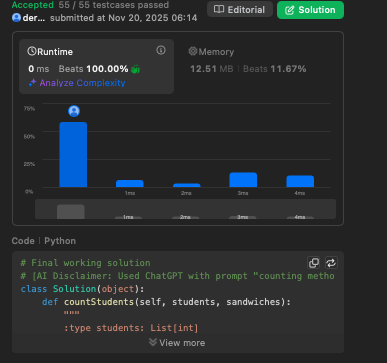

## 4. Review & Fixes
_What did you improve from your draft? 2 fixes with your comments._



In [ ]:
# Fix 1: The Draft counted preferences with two separate branches:

# Draft version
if s == 0:
    count0 += 1
else:
    count1 += 1
# Fixed version I kept the counting logic but made the intent clearer
 for s in students:
            if s == 0:
                count0 += 1
            else:
                count1 += 1


In [ ]:
# Fix 2: The Draft described the logic as if the loop would break when no one wants the current sandwich, then return the remaining count after the loop. But the code returned directly inside the loop instead of breaking.

# Draft version
 for sw in sandwiches:
            if sw == 0:
                if count0 == 0:
                    return count1   # only 1-type students left
                count0 -= 1
            else:
                if count1 == 0:
                    return count0   # only 0-type students left
                count1 -= 1
# Fixed version:
if sw == 0:
    if count0 == 0:
        return count1
...
if sw == 1:
    if count1 == 0:
        return count0



## 5. Reflection on Your Contribution
_Where did AI or Other's code helped or fail to help? What specific logic or debugging did you contribute yourself?_

1. Reading through other solutions helped me notice that the queue simulation is not actually needed. The key observation is that the process stops the moment a sandwich type appears that has no remaining students who prefer it. This idea made the whole problem much simpler than rotating the queue.
2. I also learned that using two counters for the preferences (type 0 and type 1) is enough to represent the entire queue state. This pattern of “reduce a simulation into counts” is something I can apply to similar problems later.



#  Problem 3：Climbing Stairs




## 1. Understanding & Breakdown

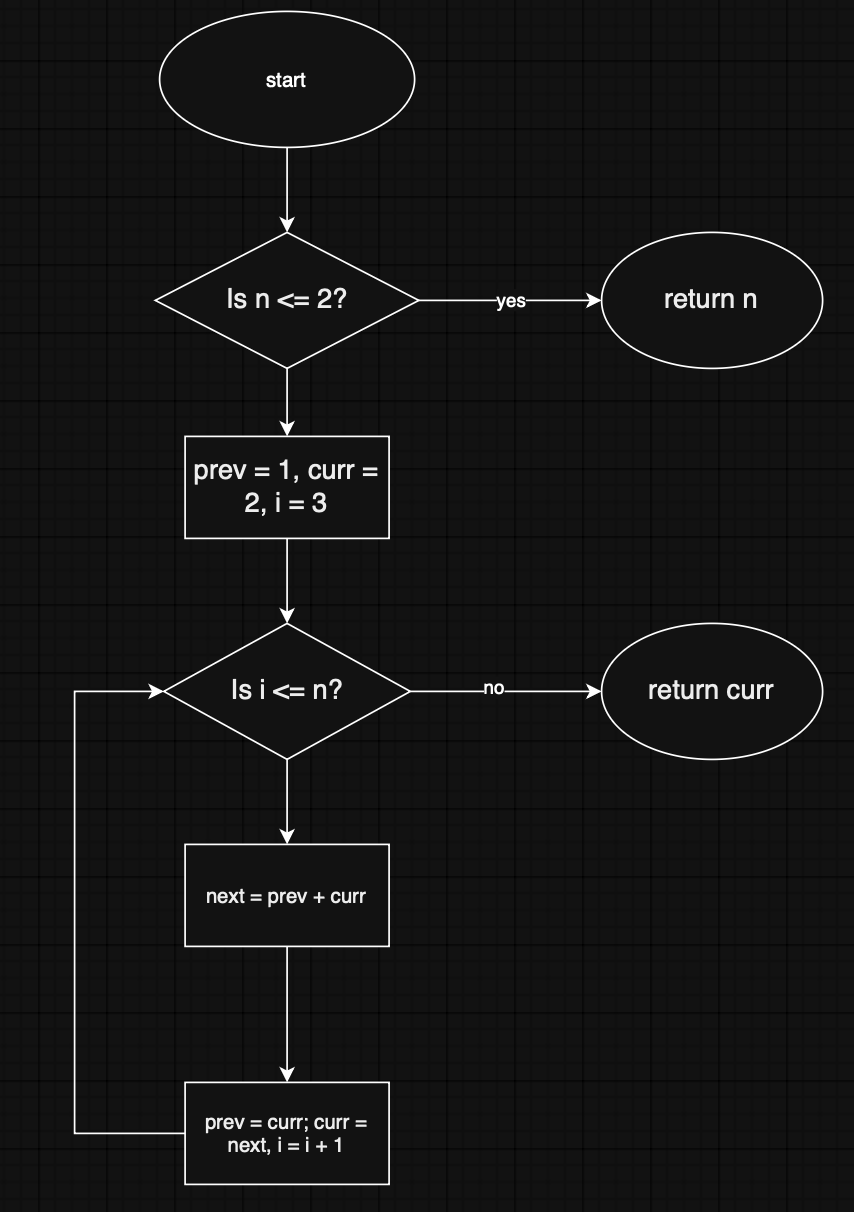

## 2. Peer Review & Draft Code


I reviewed the top solution under the LeetCode “Solutions” tab:  
https://leetcode.com/problems/climbing-stairs/solutions/7352365/best-explaination-recursion-flowchart-by-ho58/

When I checked another person’s solution, I noticed they only kept two numbers to update the count instead of storing all previous results. This helped me realize that I only need the last two values at any moment.


In [ ]:
class Solution(object):
    def climbStairs(self, n):
        """
        :type n: int
        :rtype: int
        """
        # for n <= 2, the answer is n
        if n <= 2:
            return n

        # use two variables to simulate dp
        prev = 1   # ways to reach step 1
        curr = 2   # ways to reach step 2
        i = 3

        # compute from step 3 to n
        while i <= n:
            nxt = prev + curr   # dp[i] = dp[i-1] + dp[i-2]
            prev = curr         # shift the window
            curr = nxt
            i += 1

        return curr


## 3. Final Correct Code

_This version must pass all required test cases and handle edge cases correctly._

At this stage, you may:
- Use reviewed solutions or programming AI tools (e.g., ChatGPT, GitHub Copilot) to refine and fix errors.
- Refactor your draft to ensure accuracy and completeness.

 **AI Level 4 is allowed**, but you **must include a disclaimer** that clearly states what tools you used, how you used them, and for which part of the code.


In [ ]:
# Final working solution
# [AI Disclaimer: Used ChatGPT with prompt "two-variable dp for staircase concept" only for concept]
class Solution(object):
    def climbStairs(self, n):
        """
        :type n: int
        :rtype: int
        """
        # small cases return n directly
        if n <= 2:
            return n

        # rolling values for dp
        prev = 1   # ways for step 1
        curr = 2   # ways for step 2

        # compute up to step n
        for i in range(3, n + 1):
            nxt = prev + curr
            prev = curr
            curr = nxt

        return curr

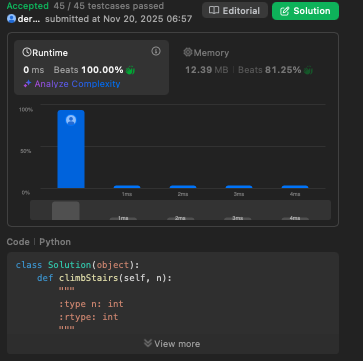

## 4. Review & Fixes
_What did you improve from your draft? 2 fixes with your comments._



In [ ]:
# Fix 1:

# Draft version
i = 3
while i <= n:
    nxt = prev + curr
    prev = curr
    curr = nxt
    i += 1

# Fixed version (cleaner and scalable)
for i in range(3, n + 1):
    nxt = prev + curr
    prev = curr
    curr = nxt


## 5. Reflection on Your Contribution
_Where did AI or Other's code helped or fail to help? What specific logic or debugging did you contribute yourself?_


1. After reviewing another solution, I realized that I didn’t need a full dp list. Using just two rolling values was enough to get each next step, which made the idea much clearer for me.

2.  I used AI to confirm that the two-variable rolling method was valid for this problem and matched the recurrence pattern I was trying to follow.


#  Problem 4：First Bad Version



## 1. Understanding & Breakdown

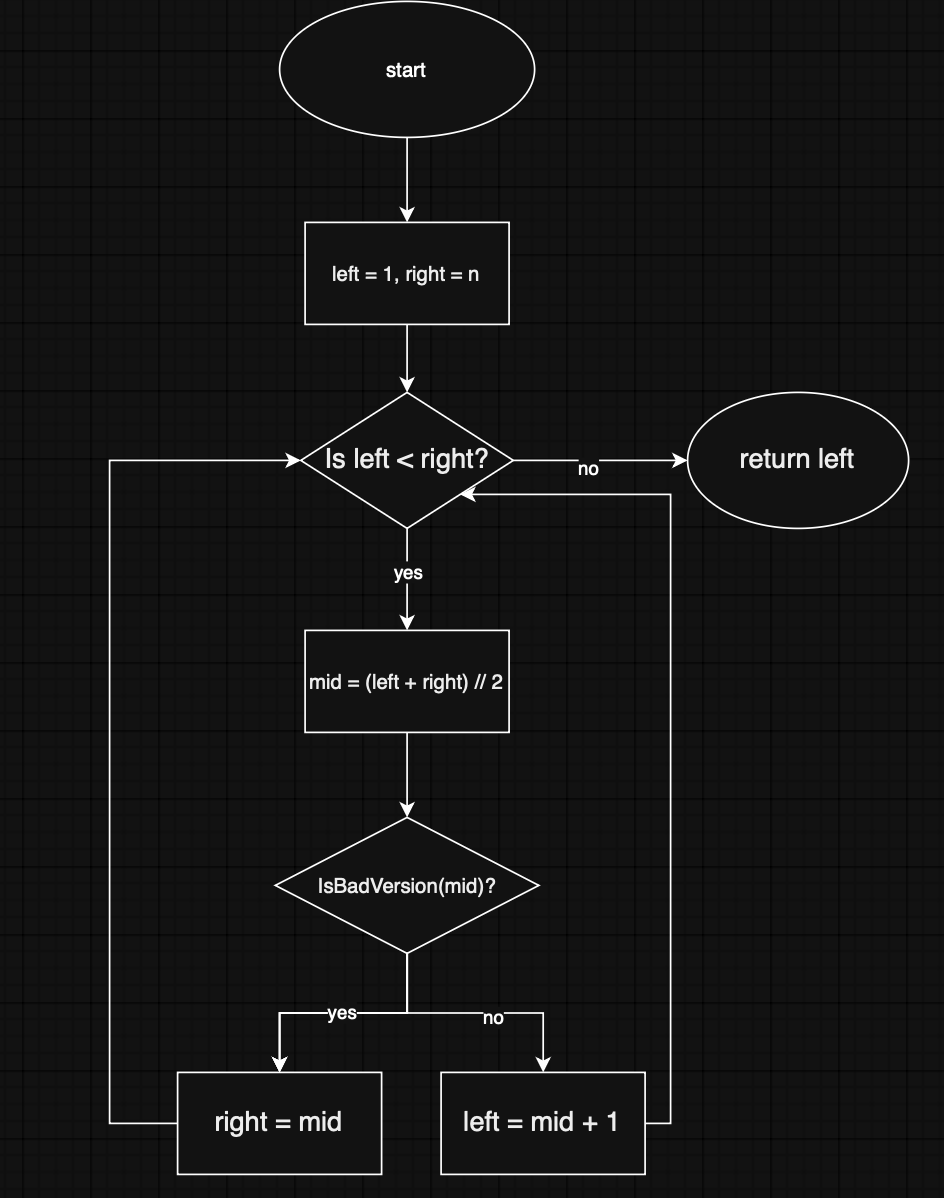

## 2. Peer Review & Draft Code

I reviewed the top solution under the LeetCode “Solutions”:  
https://leetcode.com/problems/first-bad-version/solutions/6634506/conquer-the-first-bad-version-binary-sea-m4pj/
I learned that the key idea is to always keep the first bad version inside the search range, so whenever mid is bad, we move the right pointer to mid instead of mid - 1.


In [ ]:
class Solution(object):
    def firstBadVersion(self, n):
        """
        :type n: int
        :rtype: int
        """
        left = 1
        right = n

        # binary search for the first bad version
        while left < right:
            mid = (left + right) // 2
            if isBadVersion(mid):
                # mid could be the first bad version
                right = mid
            else:
                # mid is good, so first bad is on the right side
                left = mid + 1

        return left

## 3. Final Correct Code

_This version must pass all required test cases and handle edge cases correctly._

At this stage, you may:
- Use reviewed solutions or programming AI tools (e.g., ChatGPT, GitHub Copilot) to refine and fix errors.
- Refactor your draft to ensure accuracy and completeness.

 **AI Level 4 is allowed**, but you **must include a disclaimer** that clearly states what tools you used, how you used them, and for which part of the code.


In [ ]:
# Final working solution
# [AI Disclaimer: Used ChatGPT with prompt "binary search boundary for first bad version concept" only for concept]
class Solution(object):
    def firstBadVersion(self, n):
        """
        :type n: int
        :rtype: int
        """
        left, right = 1, n

        # binary search to find the first bad version
        while left < right:
            mid = left + (right - left) // 2
            if isBadVersion(mid):
                # mid might be the first bad version, keep it in range
                right = mid
            else:
                # mid is good, so first bad must be to the right
                left = mid + 1

        return left




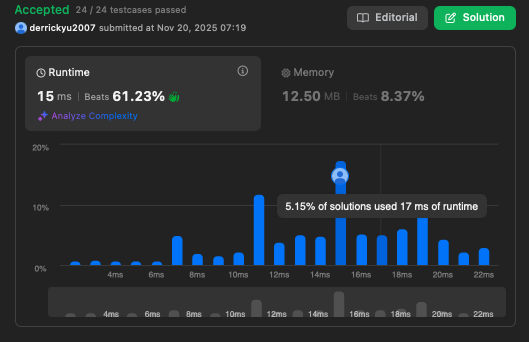

## 4. Review & Fixes
_What did you improve from your draft? 2 fixes with your comments._



In [ ]:
# Fix 1:

# Draft version less standard and can overflow in other languages.
mid = (left + right) // 2


# Fixed version (cleaner and scalable)
mid = left + (right - left) // 2

In [ ]:
# Fix 2: simplifying

# Draft version:
left = 1
right = n

# Fixed version：
left, right = 1, n


## 5. Reflection on Your Contribution
_Where did AI or Other's code helped or fail to help? What specific logic or debugging did you contribute yourself?_

1. I used AI to double-check that my binary search boundaries were correct, especially the part where right should move to mid when the version is bad.
2. I also used AI to confirm that returning left at the end is the right way to point to the first bad version once both pointers meet.



#  Problem 5：Valid Anagram




## 1. Understanding & Breakdown

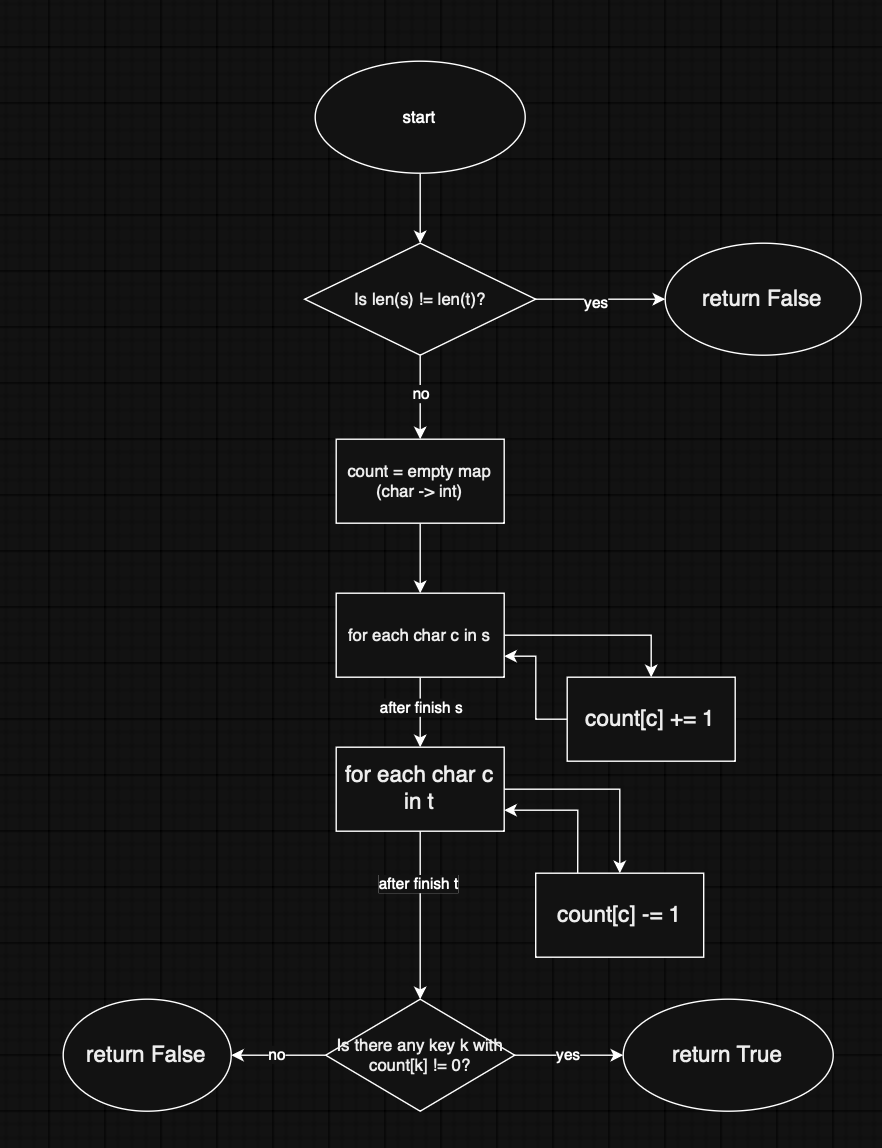

## 2. Peer Review & Draft Code

I reviewed the top solution under the LeetCode “Solutions” tab:  
https://stackoverflow.com/questions/17129222/how-to-check-if-a-number-is-palindrome-in-python  

I learned that using a fixed frequency structure for letters makes it easy to compare two strings by counting how many times each character appears instead of sorting them.


In [ ]:
class Solution(object):
    def isAnagram(self, s, t):
        """
        :type s: str
        :type t: str
        :rtype: bool
        """
        # if lengths are different, cannot be an anagram
        if len(s) != len(t):
            return False

        count = {}  # map from char to int

        # count frequency from s
        for c in s:
            if c in count:
                count[c] += 1
            else:
                count[c] = 1

        # subtract frequency using t
        for c in t:
            if c in count:
                count[c] -= 1
            else:
                count[c] = -1

        # check if all counts go back to zero
        for ch in count:
            if count[ch] != 0:
                return False

        return True

## 3. Final Correct Code

_This version must pass all required test cases and handle edge cases correctly._

At this stage, you may:
- Use reviewed solutions or programming AI tools (e.g., ChatGPT, GitHub Copilot) to refine and fix errors.
- Refactor your draft to ensure accuracy and completeness.

 **AI Level 4 is allowed**, but you **must include a disclaimer** that clearly states what tools you used, how you used them, and for which part of the code.


In [ ]:
# Final working solution
# [AI Disclaimer: Used ChatGPT with prompt "hash map counting for anagram concept" only for concept]
class Solution(object):
    def isAnagram(self, s, t):
        """
        :type s: str
        :type t: str
        :rtype: bool
        """
        # lengths must match
        if len(s) != len(t):
            return False

        count = {}  # frequency map

        # add counts from s
        for c in s:
            count[c] = count.get(c, 0) + 1

        # subtract counts using t
        for c in t:
            count[c] = count.get(c, 0) - 1

        # verify all counts return to zero
        for val in count.values():
            if val != 0:
                return False

        return True


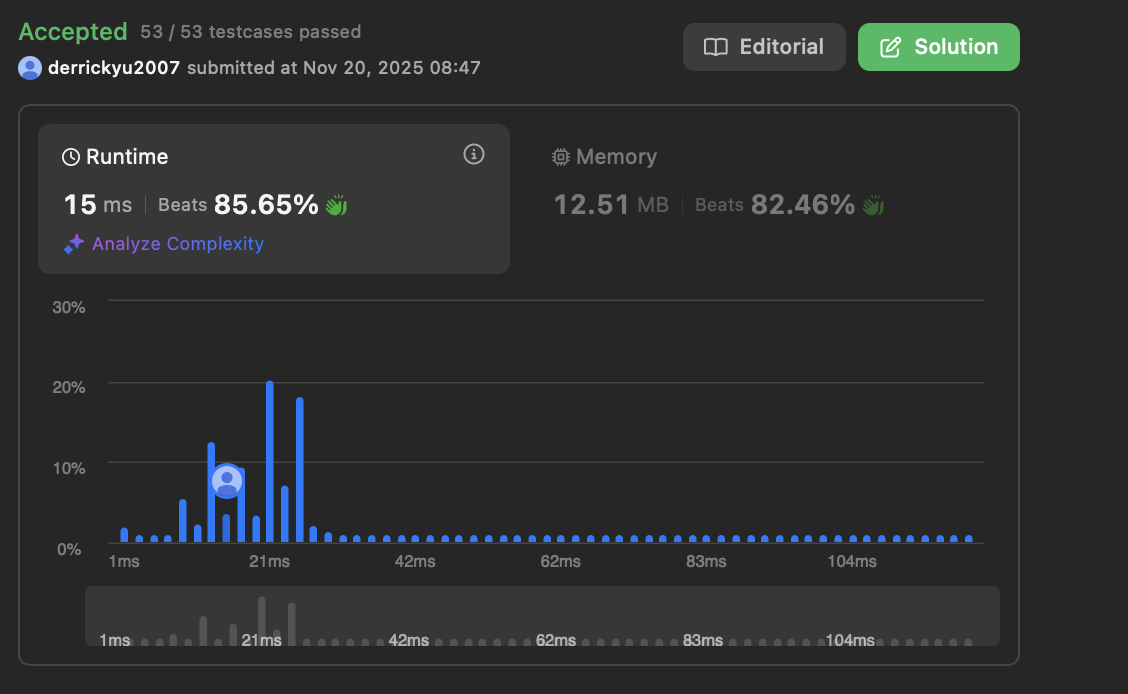

## 4. Review & Fixes
_What did you improve from your draft? 2 fixes with your comments._



In [ ]:
# Fix 1: Simplified

# Draft version
if c in count:
    count[c] += 1
else:
    count[c] = 1

# Fixed version (cleaner and simplified)
count[c] = count.get(c, 0) + 1


In [ ]:
# Fix 2: Simplified

# Draft version:
for ch in count:
    if count[ch] != 0:
        return False


# Fixed version （cleaner and simplified)
for val in count.values():
    if val != 0:
        return False



## 5. Reflection on Your Contribution
_Where did AI or Other's code helped or fail to help? What specific logic or debugging did you contribute yourself?_

1. I used AI mainly to help me simplify my original counting logic. It showed me that using get() makes the frequency updates shorter and avoids repeating the same checks, which made the code cleaner.
2. I also had ai teach me the frequency-count approach

